In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from fredapi import Fred
from dotenv import load_dotenv
import os
load_dotenv()
fred = Fred(api_key=os.getenv("FRED_API_KEY"))

In [6]:
# Federal Funds Effective Rate
fed_funds = fred.get_series('FEDFUNDS', observation_start='1990-01-01')
## CPI inflation (year-over-year)
cpi = fred.get_series('CPIAUCSL', observation_start='1990-01-01').pct_change(12) * 100
# Output gap (CBO estimate)
output_gap = fred.get_series('GDPPOT', observation_start='1990-01-01')
real_gdp = fred.get_series('GDPC1', observation_start='1990-01-01')
# Combine into dataframe
df = pd.DataFrame({
    'fed_funds': fed_funds,
    'inflation': cpi,
}).dropna()
df.index = pd.to_datetime(df.index)


Text(0.5, 1.0, 'Taylor Rule vs. Fed Funds Rate')

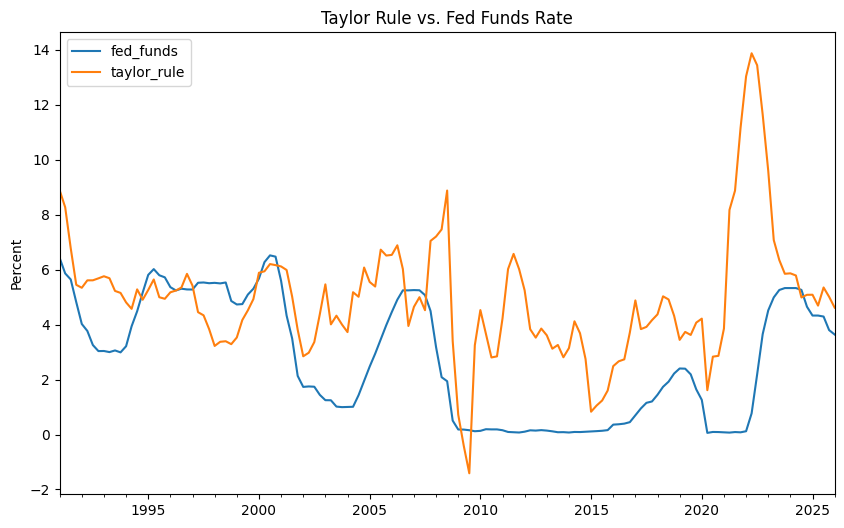

In [9]:
# Resample dataframe to quarterly frequency and take means
df_q = df.resample('QS').mean()

# Calculate Taylor Rule target rate on the quarterly data
df_q['taylor_rule'] = 2 + df_q['inflation'] + 0.5 * (df_q['inflation'] - 2)

# Plot Taylor Rule vs. Fed Funds Rate
ax = df_q[['fed_funds', 'taylor_rule']].plot(figsize=(10, 6))
ax.set_ylabel('Percent')
ax.set_title('Taylor Rule vs. Fed Funds Rate')

